# ML4Phys 2023 Assignment 3 - Solution

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = "cuda" if torch.cuda.is_available() else "cpu"
print("GPU available: ", torch.cuda.is_available())


GPU available:  True


In [2]:
class MyDataset(Dataset):
    def __init__(self, data, target, transform=None, target_transform=None):
        self.data = data
        self.target = target
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        x = self.data[index]
        if self.transform:
            x = self.transform(x)

        y = self.target[index]
        if self.target_transform:
            y = self.target_transform(y)

        return x, y

## Question 1: Data loading and pre-processing

In [3]:
!wget "http://www.astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5"

--2024-01-09 14:03:11--  http://www.astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5
Resolving www.astro.utoronto.ca (www.astro.utoronto.ca)... 128.100.89.92
Connecting to www.astro.utoronto.ca (www.astro.utoronto.ca)|128.100.89.92|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5 [following]
--2024-01-09 14:03:12--  https://www.astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5
Connecting to www.astro.utoronto.ca (www.astro.utoronto.ca)|128.100.89.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 210234548 (200M)
Saving to: ‘Galaxy10.h5’

Galaxy10.h5         100%[===================>] 200.50M  53.5MB/s    in 4.1s    

2024-01-09 14:03:16 (48.4 MB/s) - ‘Galaxy10.h5’ saved [210234548/210234548]



In [4]:
datafile = h5py.File("Galaxy10.h5")

data = np.array(datafile['images'])
labels = np.array(datafile['ans'])

data = torch.from_numpy(data)
labels = torch.from_numpy(labels)

In [5]:
data = data.type(torch.float32).permute(0,3,1,2)
labels = labels.type(torch.LongTensor)

In [6]:
tmp_batch = transforms.RandomCrop(48)(data[:1000])
channel_means = tmp_batch.mean([0,2,3])
channel_stds = tmp_batch.std([0,2,3])

In [7]:
transform = transforms.Compose([
        transforms.RandomCrop(48),
        transforms.Normalize(channel_means, channel_stds)
    ])

In [8]:
holdout_mask = (labels == 8) + (labels ==9)

main_data = data[~holdout_mask]
main_labels = labels[~holdout_mask]

transfer_data = data[holdout_mask]
transfer_labels = labels[holdout_mask] - 8

train_dataset_main = MyDataset(main_data[:18000], main_labels[:18000], transform=transform)
test_dataset_main = MyDataset(main_data[18000:], main_labels[18000:], transform=transform)

train_dataset_transfer = MyDataset(transfer_data[:1000], transfer_labels[:1000], transform=transform)
test_dataset_transfer = MyDataset(transfer_data[1000:], transfer_labels[1000:], transform=transform)

batch_size = 64

train_dataloader_main = DataLoader(train_dataset_main, batch_size=batch_size, drop_last=True, shuffle=True)
test_dataloader_main = DataLoader(test_dataset_main, batch_size=batch_size)

train_dataloader_transfer = DataLoader(train_dataset_transfer, batch_size=batch_size, drop_last=True, shuffle=True)
test_dataloader_transfer = DataLoader(test_dataset_transfer, batch_size=batch_size)

## Question 2: Fully connected network

In [9]:
def train(dataloader, model, loss_fn, optimizer, verbose=False):

    size = len(dataloader.dataset)
    model.train()
    running_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        running_loss += loss.item()

    if verbose:
        print(f"Train loss: {running_loss/len(dataloader):.2f}")

    return running_loss / len(dataloader)


def test(dataloader, model, loss_fn, verbose=True):

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size

    if verbose:
        print(f"\nTest Accuracy: {(100*correct):>0.1f}%")

    return test_loss

In [10]:
def initialize_mlp():
    return nn.Sequential(
    nn.Flatten(),
    nn.Linear(3*48*48, 64),
    nn.ReLU(),
    nn.Linear(64, 8)
).to(device)


Test Accuracy: 64.6%


0.924179961552491

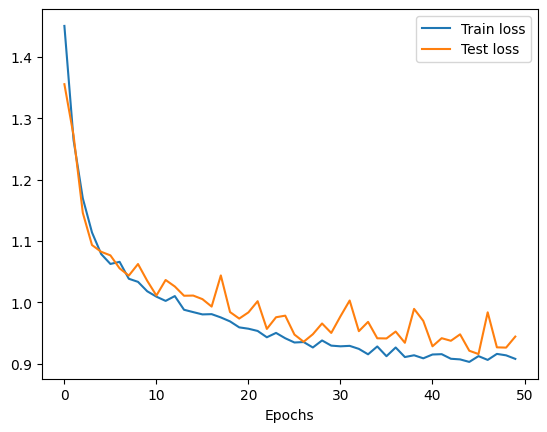

In [13]:
fcn_model = initialize_mlp()

loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.001
optimizer = torch.optim.Adam(fcn_model.parameters(), lr=learning_rate)

epochs = 50

train_loss = []
test_loss = []
for t in range(epochs):
    train_loss.append(train(train_dataloader_main, fcn_model, loss_fn, optimizer))
    test_loss.append(test(test_dataloader_main, fcn_model, loss_fn, verbose=False))

plt.plot(train_loss, label="Train loss")
plt.plot(test_loss, label="Test loss")
plt.xlabel("Epochs")
plt.legend()

test(test_dataloader_main, fcn_model, loss_fn)

## Question 3: Convolutional network

In [14]:
def initialize_backbone():
    return nn.Sequential(
        nn.Conv2d(3, 8, 5),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(8, 16, 5),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Flatten(),
        nn.Linear(16 * 9 * 9, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU()
    ).to(device)

def initialize_classifier(cl=8):
    return nn.Linear(64, cl).to(device)


Test Accuracy: 81.8%


0.49345942365156636

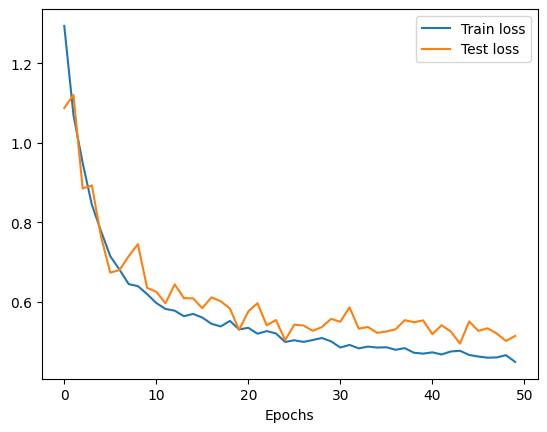

In [16]:
backbone = initialize_backbone()
classifier = initialize_classifier()

cnn_model = nn.Sequential(backbone, classifier)

loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.002
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=learning_rate)

epochs = 50

train_loss = []
test_loss = []
for t in range(epochs):
    train_loss.append(train(train_dataloader_main, cnn_model, loss_fn, optimizer))
    test_loss.append(test(test_dataloader_main, cnn_model, loss_fn, verbose=False))

plt.plot(train_loss, label="Train loss")
plt.plot(test_loss, label="Test loss")
plt.xlabel("Epochs")
plt.legend()

test(test_dataloader_main, cnn_model, loss_fn)

The CNN outperforms the FCN due to its better inductive biases (translational invariance, localiy, depth/multi-scale structure). Yet, notice that the total number of parameters of the CNN is lower (and not significantly larger as someone commented) than the one of the FCN.

In [21]:
sum(p.numel() for p in cnn_model.parameters()), sum(p.numel() for p in fcn_model.parameters())

(178616, 442952)

## Question 4: Confusion matrices

In [17]:
def plot_confusion_matrix(dataloader, model):

    labels = []
    predictions = []
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)

            labels.append(y)
            predictions.append(pred.argmax(1))

    labels = torch.cat(labels)
    predictions = torch.cat(predictions)

    cm = confusion_matrix(labels.cpu(), predictions.cpu())
    ConfusionMatrixDisplay(cm).plot()

Fully connected network


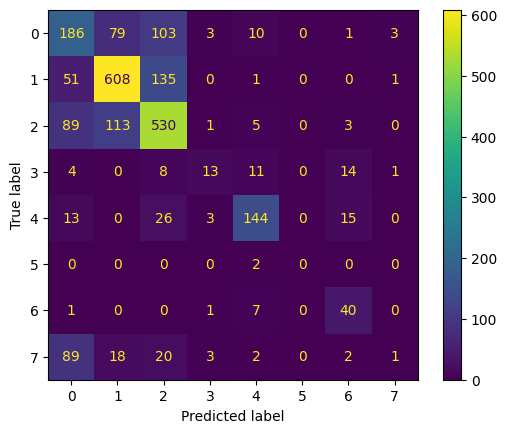

In [18]:
print("Fully connected network")
plot_confusion_matrix(test_dataloader_main, fcn_model)

Convolutional network


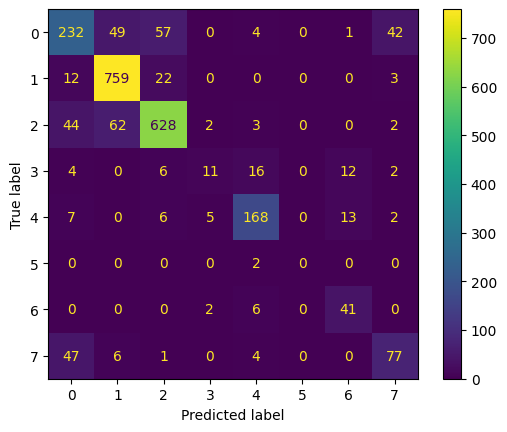

In [19]:
print("Convolutional network")
plot_confusion_matrix(test_dataloader_main, cnn_model)

Classes with fewer examples in the training set are more easily missclassified and similar classes are more prone to be confused by the models.

## Question 5: Transfer learning

In [20]:
new_classifier = initialize_classifier(2)

model = nn.Sequential(backbone, new_classifier)

for p in backbone.parameters():
    p.requires_grad_(False)

loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.005
optimizer = torch.optim.Adam(new_classifier.parameters(), lr=learning_rate)

epochs = 20

for t in range(epochs):
    train(train_dataloader_transfer, model, loss_fn, optimizer)

test(test_dataloader_transfer, model, loss_fn)


Test Accuracy: 80.9%


0.4678286143711635